In [ ]:
# # !pip install shap pmdarima tensorflow scikit-learn matplotlib pandas numpy statsmodels

# import pandas as pd
# import numpy as np
# from sklearn.preprocessing import LabelEncoder, StandardScaler
# from sklearn.feature_selection import SelectKBest, chi2

# # ===== LOAD & CLEAN DATA =====
# df = pd.read_csv('/content/banashankari_visitors_2025_corrected.csv')

# # Parse date
# df['Visit Date'] = pd.to_datetime(df['Visit Date'])
# df = df.sort_values('Visit Date').fillna(method='ffill')

# # Drop columns not needed
# if 'Full Name' in df.columns:
#     df = df.drop(columns=['Full Name'])

# # ===== SET TARGET COLUMN =====
# target_col = 'Crowd Level'
# if target_col not in df.columns:
#     raise ValueError(f"Target column '{target_col}' not found. Available columns: {df.columns.tolist()}")

# # ===== ENCODE CATEGORICAL =====
# for col in df.select_dtypes(include=['object']).columns:
#     if col != 'Visit Date' and col != target_col:
#         df[col] = LabelEncoder().fit_transform(df[col])

# # Also encode target if it's categorical
# if df[target_col].dtype == 'object':
#     df[target_col] = LabelEncoder().fit_transform(df[target_col])

# # ===== FEATURE SELECTION =====
# features = [c for c in df.columns if c not in ['Visit Date', target_col]]

# X = df[features].copy()
# # chi2 requires non-negative values
# X[X < 0] = 0
# y = df[target_col]

# selector = SelectKBest(chi2, k=min(5, X.shape[1]))
# selector.fit(X, y)
# selected_features = X.columns[selector.get_support()].tolist()
# print("✅ Selected features:", selected_features)

# # ===== SCALING =====
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(df[selected_features])

# # Final X, y for model training
# X_all = X_scaled
# y_all = y.values

# print(f"✅ Final X shape: {X_all.shape}")
# print(f"✅ Final y shape: {y_all.shape}")


✅ Selected features: ['Age Group', 'Time Slot', 'Group Size', 'Mode of Travel', 'Special Day Type']
✅ Final X shape: (1250, 5)
✅ Final y shape: (1250,)


/tmp/ipython-input-3948513116.py:13: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.sort_values('Visit Date').fillna(method='ffill')


RF MAE: 10.864481445521191
RF RMSE: 12.857024516213635
RF R2: 0.9353142775150757


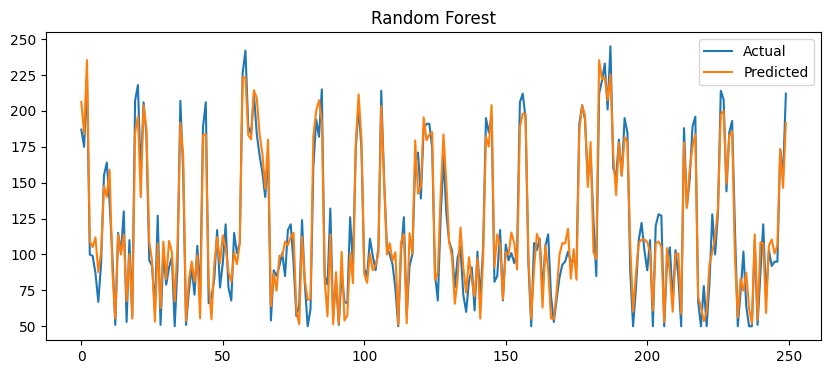

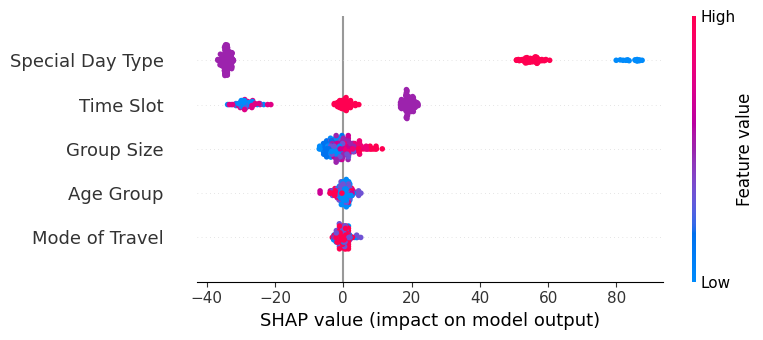

In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# import shap
# import matplotlib.pyplot as plt
# import numpy as np

# X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, shuffle=False)

# rf = RandomForestRegressor(n_estimators=200, random_state=42)
# rf.fit(X_train, y_train)
# y_pred = rf.predict(X_test)

# print("RF MAE:", mean_absolute_error(y_test, y_pred))
# print("RF RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
# print("RF R2:", r2_score(y_test, y_pred))

# plt.figure(figsize=(10,4))
# plt.plot(y_test, label="Actual")
# plt.plot(y_pred, label="Predicted")
# plt.legend(); plt.title("Random Forest"); plt.show()

# explainer = shap.TreeExplainer(rf)
# shap_values = explainer.shap_values(X_test)
# shap.summary_plot(shap_values, X_test, feature_names=selected_features)


✅ MAE: 9.63
✅ RMSE: 11.79
✅ R² Score: 0.9531
Special Day Type: 0.8082
Time Slot: 0.1430
Month: 0.0119
Weekday: 0.0063
Day: 0.0166
Group Size: 0.0140


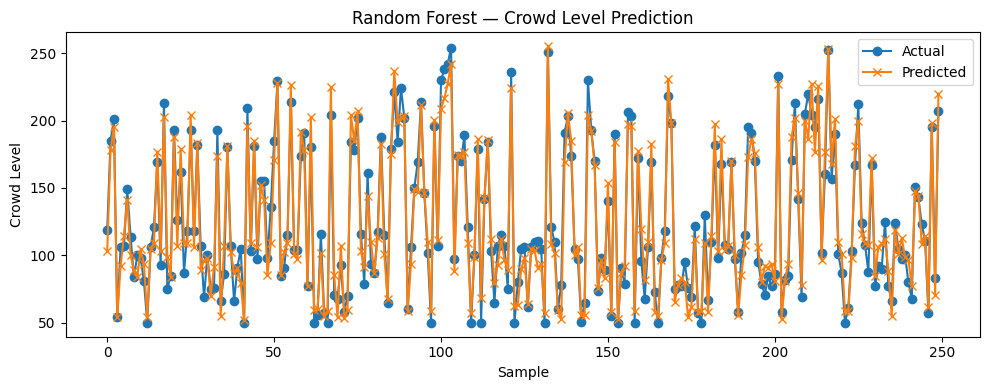

In [ ]:


import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib


df = pd.read_csv('/content/banashankari_visitors_2025_corrected.csv')


cols_to_drop = ['Full Name', 'Mode of Travel', 'Waiting Tolerance', 'Visit Purpose', 'Age Group', 'Is_Weekend']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')


df['Visit Date'] = pd.to_datetime(df['Visit Date'])
df['Month'] = df['Visit Date'].dt.month
df['Day'] = df['Visit Date'].dt.day
df['Weekday'] = df['Visit Date'].dt.weekday
df = df.drop(columns=['Visit Date'])


for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])


target = 'Crowd Level'
selected_features = ['Special Day Type', 'Time Slot', 'Month', 'Weekday', 'Day', 'Group Size']

X = df[selected_features]
y = df[target]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


model = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
print(f"✅ MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"✅ RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"✅ R² Score: {r2_score(y_test, y_pred):.4f}")


importances = model.feature_importances_
for name, imp in zip(selected_features, importances):
    print(f"{name}: {imp:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(y_test.values, label='Actual', marker='o')
plt.plot(y_pred, label='Predicted', marker='x')
plt.legend()
plt.title('Random Forest — Crowd Level Prediction')
plt.xlabel('Sample')
plt.ylabel('Crowd Level')
plt.tight_layout()
plt.show()


In [ ]:
# plt.figure(figsize=(10, 4))
# plt.plot(y_test.values, label='Actual', marker='o')
# plt.plot(y_pred, label='Predicted', marker='x')
# plt.legend()
# plt.title('Random Forest — Crowd Level Prediction')
# plt.xlabel('Sample')
# plt.ylabel('Crowd Level')
# plt.tight_layout()
# plt.show()

✅ MAE: 9.56
✅ RMSE: 11.44
✅ R² Score: 0.9559

📌 Feature Importance:
Special Day Type: 0.8147
Time Slot: 0.1437
Day: 0.0102
Group Size: 0.0090
Month: 0.0071
Waiting Tolerance: 0.0051
Age Group: 0.0036
Weekday: 0.0036
Visit Purpose: 0.0026
Is_Weekend: 0.0004


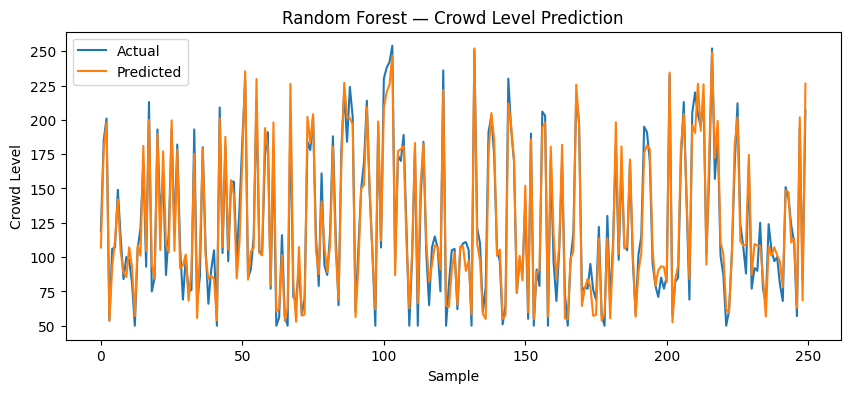

In [ ]:
# # ================================
# # 📊 CROWD LEVEL PREDICTION MODEL
# # ================================

# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import LabelEncoder, StandardScaler
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# # ===== 1. LOAD DATA =====
# df = pd.read_csv('/content/banashankari_visitors_2025_corrected.csv')

# # ===== 2. DROP UNUSED COLUMNS =====
# # Remove personal identifiers and Mode of Travel
# drop_cols = []
# if 'Full Name' in df.columns:
#     drop_cols.append('Full Name')
# if 'Mode of Travel' in df.columns:
#     drop_cols.append('Mode of Travel')

# df = df.drop(columns=drop_cols, errors='ignore')

# # ===== 3. FEATURE ENGINEERING =====
# # Convert Visit Date to datetime
# df['Visit Date'] = pd.to_datetime(df['Visit Date'])

# # Extract useful date features
# df['Month'] = df['Visit Date'].dt.month
# df['Day'] = df['Visit Date'].dt.day
# df['Weekday'] = df['Visit Date'].dt.weekday
# df['Is_Weekend'] = df['Weekday'].isin([5, 6]).astype(int)

# # Drop original date column
# df = df.drop(columns=['Visit Date'])

# # ===== 4. ENCODE CATEGORICAL FEATURES =====
# label_encoders = {}
# for col in df.select_dtypes(include='object').columns:
#     le = LabelEncoder()
#     df[col] = le.fit_transform(df[col])
#     label_encoders[col] = le

# # ===== 5. DEFINE TARGET & FEATURES =====
# target = 'Crowd Level'
# if target not in df.columns:
#     raise ValueError(f"❌ Target column '{target}' not found. Available: {df.columns.tolist()}")

# X = df.drop(columns=[target])
# y = df[target]

# # ===== 6. SCALING =====
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# # ===== 7. TRAIN / TEST SPLIT =====
# X_train, X_test, y_train, y_test = train_test_split(
#     X_scaled, y, test_size=0.2, shuffle=True, random_state=42
# )

# # ===== 8. TRAIN MODEL =====
# model = RandomForestRegressor(
#     n_estimators=300,
#     max_depth=15,
#     min_samples_split=5,
#     min_samples_leaf=2,
#     random_state=42,
#     n_jobs=-1
# )
# model.fit(X_train, y_train)

# # ===== 9. PREDICT & EVALUATE =====
# y_pred = model.predict(X_test)

# mae = mean_absolute_error(y_test, y_pred)
# rmse = np.sqrt(mean_squared_error(y_test, y_pred))   # ✅ compatible with old sklearn
# r2 = r2_score(y_test, y_pred)

# print(f"✅ MAE: {mae:.2f}")
# print(f"✅ RMSE: {rmse:.2f}")
# print(f"✅ R² Score: {r2:.4f}")

# # ===== 10. FEATURE IMPORTANCE =====
# importances = model.feature_importances_
# feature_names = X.columns
# sorted_idx = np.argsort(importances)[::-1]

# print("\n📌 Feature Importance:")
# for idx in sorted_idx:
#     print(f"{feature_names[idx]}: {importances[idx]:.4f}")

# # ===== 11. OPTIONAL: PLOT RESULTS =====
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 4))
# plt.plot(y_test.values, label='Actual')
# plt.plot(y_pred, label='Predicted')
# plt.legend()
# plt.title('Random Forest — Crowd Level Prediction')
# plt.xlabel('Sample')
# plt.ylabel('Crowd Level')
# plt.show()


In [ ]:
print("✅ Features used in training:")
print(list(X.columns))

✅ Features used in training:
['Special Day Type', 'Time Slot', 'Month', 'Weekday', 'Day', 'Group Size']


In [ ]:
import joblib
joblib.dump(model, "crowd_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [ ]:
import joblib

# Save model, scaler, and feature list
joblib.dump(model, "crowd_level_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(X.columns), "selected_features.pkl")

print("✅ Model, scaler, and features saved successfully!")


✅ Model, scaler, and features saved successfully!


In [ ]:
from google.colab import files
files.download("crowd_level_model.pkl")
files.download("scaler.pkl")
files.download("selected_features.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>